In [103]:
from vectorbtpro import *
import os
from zoneinfo import ZoneInfo
from datetime import datetime
from dateutil.relativedelta import relativedelta
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import math
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from tqdm import tqdm
from arch.univariate import HARX

In [2]:
os.environ["TZ"] = "UTC"
END_DATE = datetime.now(ZoneInfo("UTC")).strftime("%Y-%m-%d")
START_DATE = (datetime.now(ZoneInfo("UTC")) - relativedelta(years=6)).strftime("%Y-%m-%d")
print(f"{START_DATE} to {END_DATE}")

2020-05-29 to 2026-05-29


In [3]:
QQQ_TICKERS = [
    "NVDA", "AAPL", "MSFT", "AMZN", "GOOGL", "MU", "GOOG", "TSLA", "AMD", "AVGO",
    "META", "WMT", "INTC", "COST", "CSCO", "NFLX", "LRCX", "AMAT", "PLTR", "TXN",
    "KLAC", "QCOM", "LIN", "TMUS", "ADBE", "PEP", "HON", "INTU", "ISRG",
    "ADP", "BKNG", "VRTX", "REGN", "MDLZ", "GILD", "ADI", "PANW", "MDB", "CRWD",
    "MRVL", "CDNS", "SNPS", "FTNT", "ROST", "ABNB", "MNST", "KHC", "MELI", "PCAR",
    "ORLY", "ODFL", "DXCM", "FAST", "CTAS", "CPRT", "EXC", "IDXX", "VRSK",
    "TTD", "TTWO", "WDAY", "DDOG", "ZS", "FANG", "ON", "TEAM",
    "SIRI", "ILMN", "ENPH", "ZM", "DLTR", "BIIB",
    "MRNA", "NXPI", "ALGN", "CTSH", "CCEP", "MCHP", "CDW", "PAYX",
    "EA", "WBD", "SBUX", "PYPL", "ASML", "AZN", "PDD", "CHTR",
]

In [4]:
warnings.simplefilter("ignore")
market_data = vbt.YFData.pull(
    QQQ_TICKERS,
    start=START_DATE,
    end=END_DATE,
    timeframe="1 day",
    tz="UTC"
)
market_data = market_data.realign(ffill=True).dropna()

  8%|7         | 7/88 [00:02<00:24,  3.25it/s, symbol=TSLA]

In [5]:
df = market_data.get("Close")
ret = df.pct_change().dropna()

In [6]:
rand_assets = np.random.randint(ret.shape[1], size=3)
rand_asset_idx = rand_assets[0]

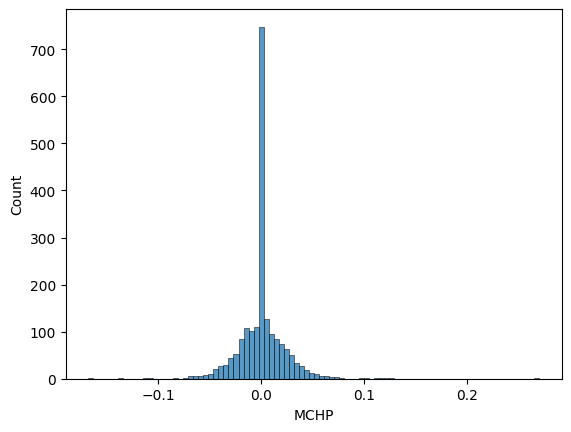

In [7]:
sns.histplot(ret.iloc[:,rand_asset_idx])
plt.show()

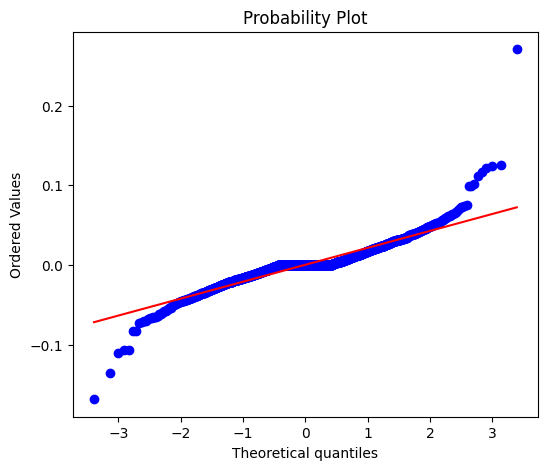

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
stats.probplot(ret.iloc[:,rand_asset_idx], dist="norm", plot=ax)
plt.show()

In [9]:
ser = ret.iloc[:,rand_asset_idx]

In [10]:
var = np.zeros(ser.shape)
mu = np.zeros(ser.shape)

In [11]:
var[0] = (0.20/math.sqrt(252))**2
mu[0] = 0

In [12]:
span = 20
lam = 2/(span+1)
for t in range(1,ser.shape[0]):
    mu[t] = lam*ser[t] + (1-lam)*mu[t-1]
    var[t] = lam*((ser[t]-mu[t])**2)+(1-lam)*var[t-1]

In [13]:
sigma = np.sqrt(var)

<Axes: ylabel='Count'>

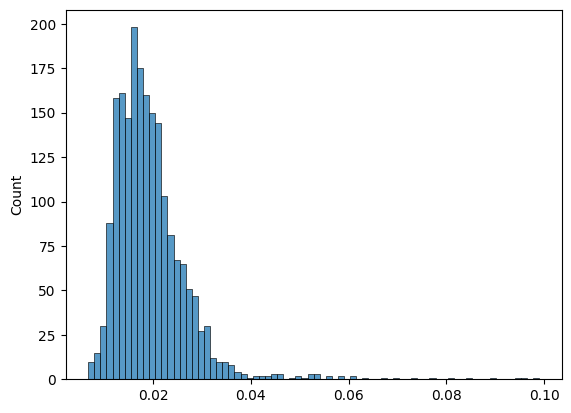

In [14]:
sns.histplot(sigma)

In [15]:
time_horizons = [1,5,20,60,252]

In [16]:
data = dict()
span=20
for h in time_horizons:
    ret = df.pct_change(h).dropna()
    sigma = ret.ewm(span=span, adjust=False).std(bias=True)
    data[h] = ret / (sigma * np.sqrt(h))

In [17]:
df1 = pd.concat(data, axis=1).dropna()

In [18]:
T_s, T_l = 8, 24
macd   = df1.ewm(span=T_s, adjust=False).mean() - df1.ewm(span=T_l, adjust=False).mean()
q      = macd / df1.rolling(63).std()
signal = q / q.rolling(252).std()
signal = signal.dropna()

In [19]:
df2 = pd.concat({'ret': df1, 'macd': signal}, axis=1)

In [20]:
df2.shape

(1743, 880)

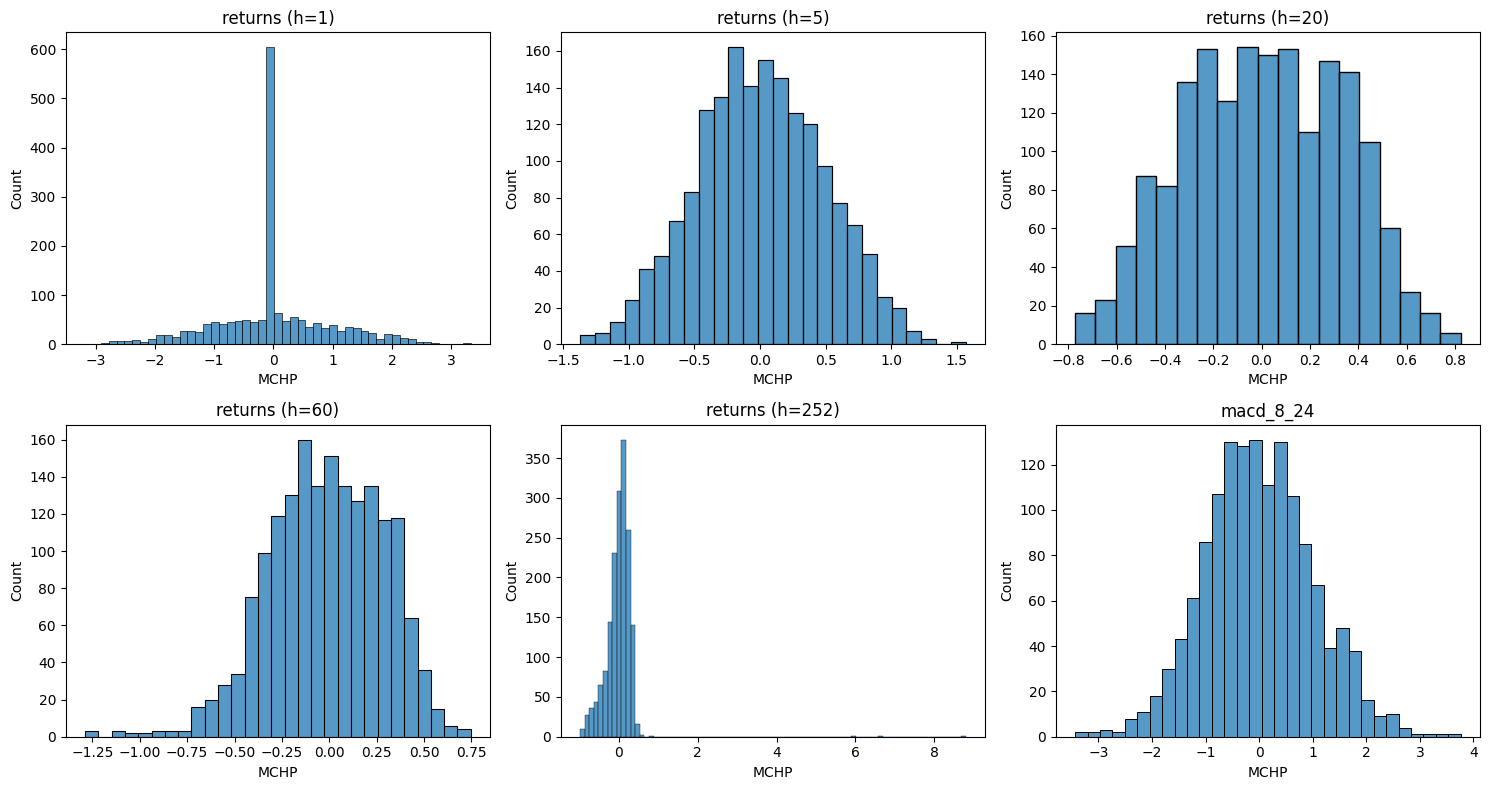

In [21]:
fig, ax = plt.subplots(2,3, figsize=(15,8))
for i in range(3):
    df_tmp = df2[('ret',time_horizons[i])]
    sns.histplot(df_tmp.iloc[:,rand_asset_idx], ax=ax[0,i])
    ax[0,i].set_title(f"returns (h={time_horizons[i]})")

for i in range(2):
    df_tmp = df2[('ret',time_horizons[i+3])]
    sns.histplot(df_tmp.iloc[:,rand_asset_idx], ax=ax[1,i])
    ax[1,i].set_title(f"returns (h={time_horizons[i+3]})")

sns.histplot(df2[('macd',time_horizons[0])].iloc[:,rand_asset_idx], ax=ax[1,2])
ax[1,2].set_title(f"macd_{T_s}_{T_l}")

plt.tight_layout()
plt.show()

In [22]:
ret = df.pct_change(h).dropna()
vs_factor = 1/ret.ewm(span=span, adjust=False).std(bias=True)

<Axes: xlabel='MCHP', ylabel='Count'>

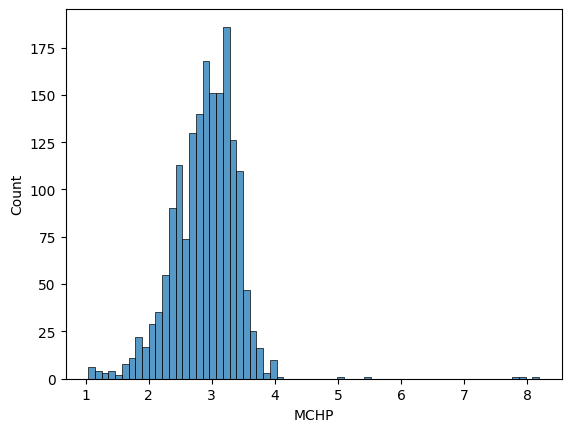

In [23]:
sns.histplot(np.log(vs_factor.iloc[:,rand_asset_idx]))

In [24]:
result = adfuller(ret.iloc[rand_asset_idx].dropna())
print(f"[{ret.columns[rand_asset_idx]}] ADF stat: {result[0]:.4f}, p-value: {result[1]:.4f}")

[MCHP] ADF stat: -8.3300, p-value: 0.0000


In [25]:
adf = ret.iloc[:,rand_assets].apply(lambda col: adfuller(col.dropna())[:2])
adf.index = ['stat', 'p-value']
adf = adf.T
# p < 0.05 → reject unit root → stationary
stationary = adf[adf['p-value'] < 0.05]
stationary

,stat,p-value
symbol,,
MCHP,-2.957948,0.039013
PANW,-3.003023,0.034613


In [26]:
from scipy.stats import jarque_bera

jb = ret.iloc[:,rand_assets].apply(lambda col: jarque_bera(col.dropna())[:2])
jb.index = ['stat', 'p-value']
jb = jb.T
# p < 0.05 → reject normality
# p >= 0.05 → fail to reject normality
normal = jb[jb['p-value'] >= 0.05]
normal

,stat,p-value
symbol,,


In [27]:
ser = df2[('ret',time_horizons[0])].iloc[:,rand_asset_idx]

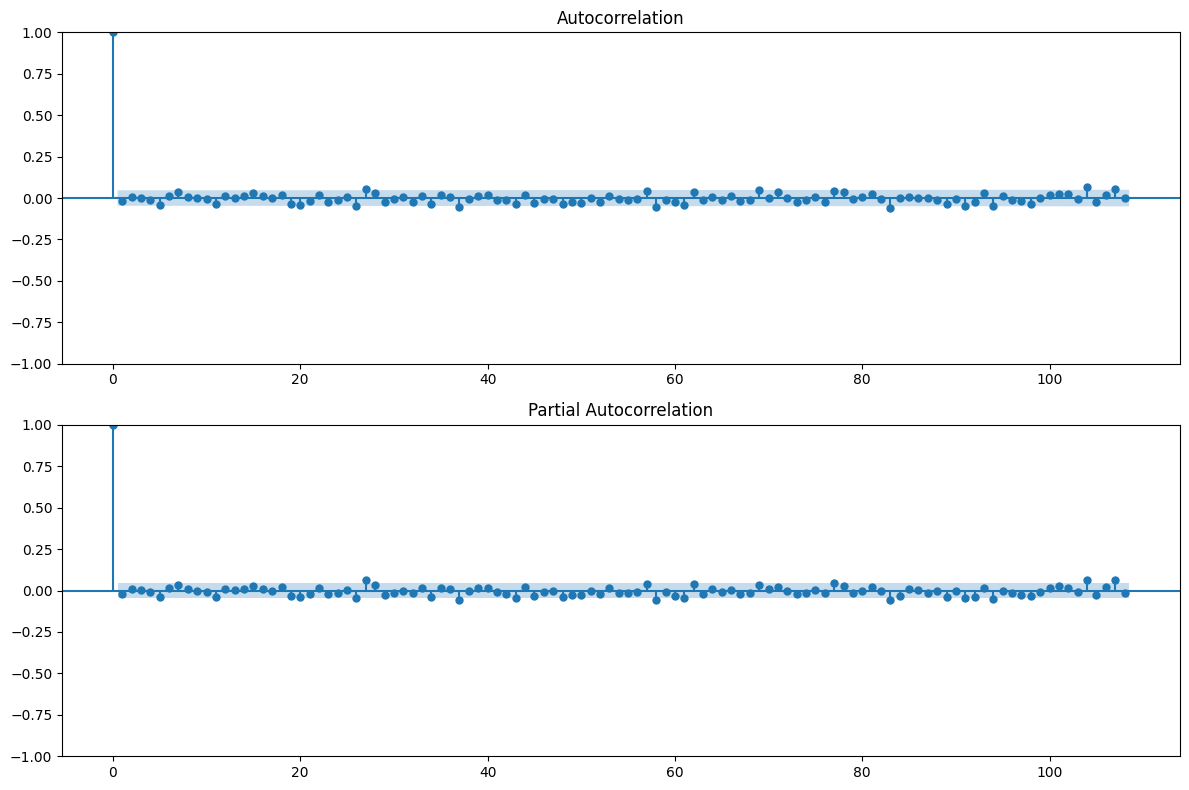

In [28]:
m=ser.shape[0]//16
fig,ax = plt.subplots(2,1,figsize=(12,8))
plot_acf(ser, lags=m, ax=ax[0])
plot_pacf(ser, lags=m, ax=ax[1])
plt.tight_layout()
plt.show()

In [92]:
tickers = df2.columns.get_level_values(2).unique()   # level-2 labels, in order
chosen  = tickers[rand_assets]                       # positions -> labels
df3 = df2.loc[:, (slice(None), [time_horizons[1], time_horizons[2]], list(chosen))].dropna()

In [119]:
LOOKBACK = 60
P=10
S=5

In [120]:
n_assets   = len(chosen)     # 3  — return columns only
n_features = df3.shape[1]    # 6  — ret + macd, used as input features

class ReturnDataset(Dataset):
  def __init__(self, arr, n_targets=n_assets):
      self.arr       = torch.tensor(arr, dtype=torch.float32)
      self.n_targets = n_targets

  def __len__(self):
      return len(self.arr) - LOOKBACK

  def __getitem__(self, i):
      X = self.arr[i : i + LOOKBACK]                    # (LOOKBACK, 6) — all features
      y = self.arr[i + LOOKBACK, : self.n_targets]      # (3,) — ret columns only
      return X, y

vals  = df3.values
T     = len(vals)
n_tr  = int(0.70 * T)
n_val = int(0.15 * T)

train_ds = ReturnDataset(vals[:n_tr])
val_ds   = ReturnDataset(vals[n_tr  - LOOKBACK : n_tr + n_val])
test_ds  = ReturnDataset(vals[n_tr + n_val - LOOKBACK :])

BATCH    = 32
train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False)
test_dl  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False)

print(f"train={len(train_ds)}  val={len(val_ds)}  test={len(test_ds)}")

train=940  val=214  test=215


In [127]:
LOOKBACK = 60
P        = 10
S        = 5
N_PATCH  = (LOOKBACK - P) // S + 1   # = 11

class LPATCHTST(nn.Module):
  def __init__(self, n_channels, hidden_size=64, num_layers=2,
               dropout=0.2, n_targets=3):
      super().__init__()
      self.hidden_size = hidden_size

      # eq 52: ONE shared LSTM — input_size=1 (scalar per channel per step)
      # same weights process every channel independently
      self.lstm = nn.LSTM(
          input_size  = 1,
          hidden_size = hidden_size,
          num_layers  = num_layers,
          batch_first = False,
          dropout     = dropout if num_layers > 1 else 0.0
      )

      # compress P hidden state vectors per patch into one token
      self.patch_proj = nn.Linear(hidden_size * P, hidden_size)

      # eq 53: Transformer attends across N_PATCH patch tokens
      self.encoder = nn.TransformerEncoder(
          nn.TransformerEncoderLayer(d_model=hidden_size, nhead=4,
                                     batch_first=False, dropout=dropout),
          num_layers=2
      )
      self.head = nn.Linear(hidden_size, n_targets)

  def forward(self, x):
      # x: (LOOKBACK=60, batch, n_channels=C)
      L, B, C = x.shape

      # --- eq 52: shared LSTM, channel-independent ---
      # merge C into batch so one LSTM processes all channels with shared weights
      x_ci = x.permute(0, 2, 1).reshape(L, B * C, 1)   # (L, B*C, 1)
      out, _ = self.lstm(x_ci)                           # (L, B*C, hidden)
      H = out.reshape(L, B, C, self.hidden_size)         # (L, B, C, hidden)

      # --- eq 53: segment h_t^(i) into temporal patches ---
      patches = H.unfold(0, P, S)                        # (N_p, B, C, hidden, P)
      patch_tokens = self.patch_proj(patches.flatten(-2, -1))
      # (N_p, B, C, hidden*P) → Linear → (N_p, B, C, hidden)

      # channel-independent Transformer: merge C into batch
      patch_tokens = patch_tokens.reshape(N_PATCH, B * C, self.hidden_size)
      # (N_p, B*C, hidden)

      encoded = self.encoder(patch_tokens)               # (N_p, B*C, hidden)

      # take final patch token, mean-pool across channels
      h_last = encoded[-1].reshape(B, C, self.hidden_size)  # (B, C, hidden)
      return self.head(h_last.mean(dim=1))               # (B, n_targets)

In [128]:
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model     = LPATCHTST(n_channels=df3.shape[1]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.MSELoss()
EPOCHS    = 13 # sweet spot

train_losses, val_losses = [], []

with tqdm(total=EPOCHS, desc="Training") as pbar:
    for epoch in range(1, EPOCHS + 1):
      # --- train ---
      model.train()
      total = 0.0
      for X, y in train_dl:
          # DataLoader gives (batch, seq, feat); LSTM wants (seq, batch, feat)
          X = X.permute(1, 0, 2).to(device)
          y = y.to(device)
          optimizer.zero_grad()
          loss = criterion(model(X), y)
          loss.backward()
          nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # prevent exploding gradients
          optimizer.step()
          total += loss.item() * y.size(0)
      train_losses.append(total / len(train_ds))
    
      # --- validate ---
      model.eval()
      total = 0.0
      with torch.no_grad():
          for X, y in val_dl:
              X = X.permute(1, 0, 2).to(device)
              loss = criterion(model(X), y.to(device))
              total += loss.item() * y.size(0)
      val_losses.append(total / len(val_ds))
      pbar.set_postfix(loss=f"{val_losses[-1]:.4f}")  
      pbar.update(1)
    
      # if epoch % 10 == 0:
      #     print(f"epoch {epoch:3d}  train={train_losses[-1]:.4f}  val={val_losses[-1]:.4f}")

Training:  15%|█▌        | 2/13 [00:09<00:51,  4.64s/it, loss=0.5307]


KeyboardInterrupt: 

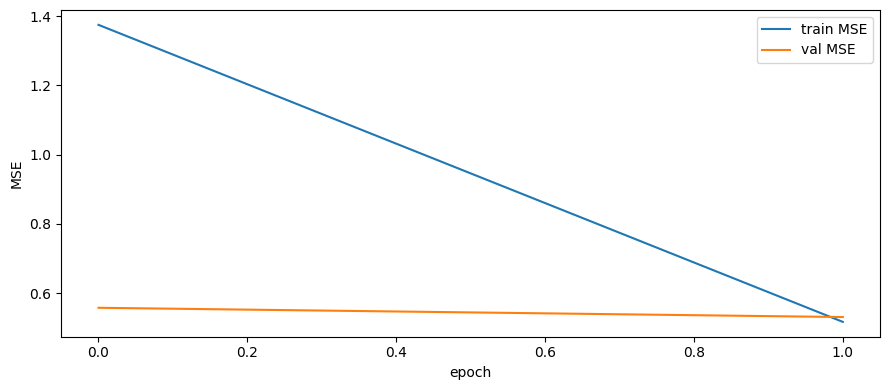

Test MSE: 0.6641  |  Mean IC: 0.0509


In [129]:
# Loss curve
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_losses, label="train MSE")
ax.plot(val_losses,   label="val MSE")
ax.set_xlabel("epoch"); ax.set_ylabel("MSE"); ax.legend()
plt.tight_layout(); plt.show()

# Test predictions
model.eval()
preds, targets = [], []
with torch.no_grad():
  for X, y in test_dl:
      preds.append(model(X.permute(1, 0, 2).to(device)).cpu())
      targets.append(y)

preds   = torch.cat(preds).numpy()    # (N_test, 3)
targets = torch.cat(targets).numpy()  # (N_test, 3)

test_mse = ((preds - targets) ** 2).mean()
# Information coefficient — rank correlation between prediction and realized return
ic = pd.DataFrame(preds).corrwith(pd.DataFrame(targets)).mean()
print(f"Test MSE: {test_mse:.4f}  |  Mean IC: {ic:.4f}")

In [130]:
rebal_every = 5   # hold each position for one full prediction horizon

test_start_idx = n_tr + n_val
test_dates     = df3.index[test_start_idx : test_start_idx + len(preds)]

# df3 columns: ('ret',5,t1),('ret',5,t2),('ret',5,t3),('macd',5,t1),...
# first 3 cols are the normalized return predictions — those drive trading
n_assets   = len(chosen)
ret_preds  = pd.DataFrame(preds[:, :n_assets], index=test_dates, columns=chosen)

# actual close prices for the same window
close_test = df.loc[rebal_dates, list(chosen)]

# only generate a new signal every 5 days
rebal_idx   = np.arange(0, len(test_dates), rebal_every)
rebal_dates = test_dates[rebal_idx]

ret_preds_5d = ret_preds.iloc[rebal_idx]   # (N/5, 3)

In [131]:
# realised vol of each asset over the past 20 days (in daily return space)
hist_vol = (
  df.loc[test_dates, list(chosen)]
    .pct_change()
    .rolling(20).std()
    .iloc[rebal_idx]         # sample on rebalance days only
)

TARGET_VOL = 0.15 / np.sqrt(252)   # 15% annualised → daily
MAX_POS    = 0.40                  # max 40% in any single name

# cross-sectional rank → demeaned signal (long/short market-neutral)
ranked      = ret_preds_5d.rank(axis=1)
base_alloc  = ranked.sub(ranked.mean(axis=1), axis=0)          # demean
base_alloc = base_alloc.clip(lower=0) # no shorts
base_alloc  = base_alloc.div(base_alloc.abs().sum(axis=1), axis=0)  # |sum|=1

# vol-scale: shrink large positions in high-vol names
vol_scaled  = base_alloc.div(hist_vol.values + 1e-8, axis=0)
vol_scaled  = vol_scaled.mul(TARGET_VOL)                       # target portfolio vol
vol_scaled  = vol_scaled.clip(-MAX_POS, MAX_POS)               # cap individual names

In [132]:
REBAL_THRESHOLD = 0.05   # only rebalance a position if weight shifts by >5%

# forward-fill current weights and only update where delta > threshold
weights_5d    = vol_scaled
prev_weights  = weights_5d.shift(1).fillna(0)
delta         = (weights_5d - prev_weights).abs()
# keep old weight where change is small
weights_5d    = prev_weights.where(delta < REBAL_THRESHOLD, weights_5d)

# expand 5-day weights to daily grid (hold position between rebalances)
weights_daily = weights_5d.reindex(test_dates).ffill().fillna(0)

In [133]:
pf = vbt.Portfolio.from_orders(
  close     = close_test,
  size      = weights_daily,
  size_type = 'targetpercent',
  fees      = 0.001,      # 10 bps one-way commission
  slippage  = 0.0005,     # 5 bps market impact
  freq      = '1D',
)

print(pf.stats())
# pf.plot(column=chosen[0]).show()

# turnover per year — proxy for tax drag
daily_turnover = weights_daily.diff().abs().sum(axis=1)
print(f"Ann. turnover: {daily_turnover.sum() / (len(test_dates)/252):.1%}")

Start Index                   2025-10-26 00:00:00+00:00
End Index                     2026-05-28 00:00:00+00:00
Total Duration                        215 days 00:00:00
Start Value                                       100.0
Min Value                                     99.885776
Max Value                                    100.237932
End Value                                      100.0016
Total Return [%]                                 0.0016
Benchmark Return [%]                          23.714636
Position Coverage [%]                         30.232558
Max Gross Exposure [%]                        13.341341
Max Drawdown [%]                               1.048981
Max Drawdown Duration                 151 days 00:00:00
Total Orders                                       13.0
Total Fees Paid                                 0.01449
Total Trades                                        7.0
Win Rate [%]                                       70.0
Best Trade [%]                                 1

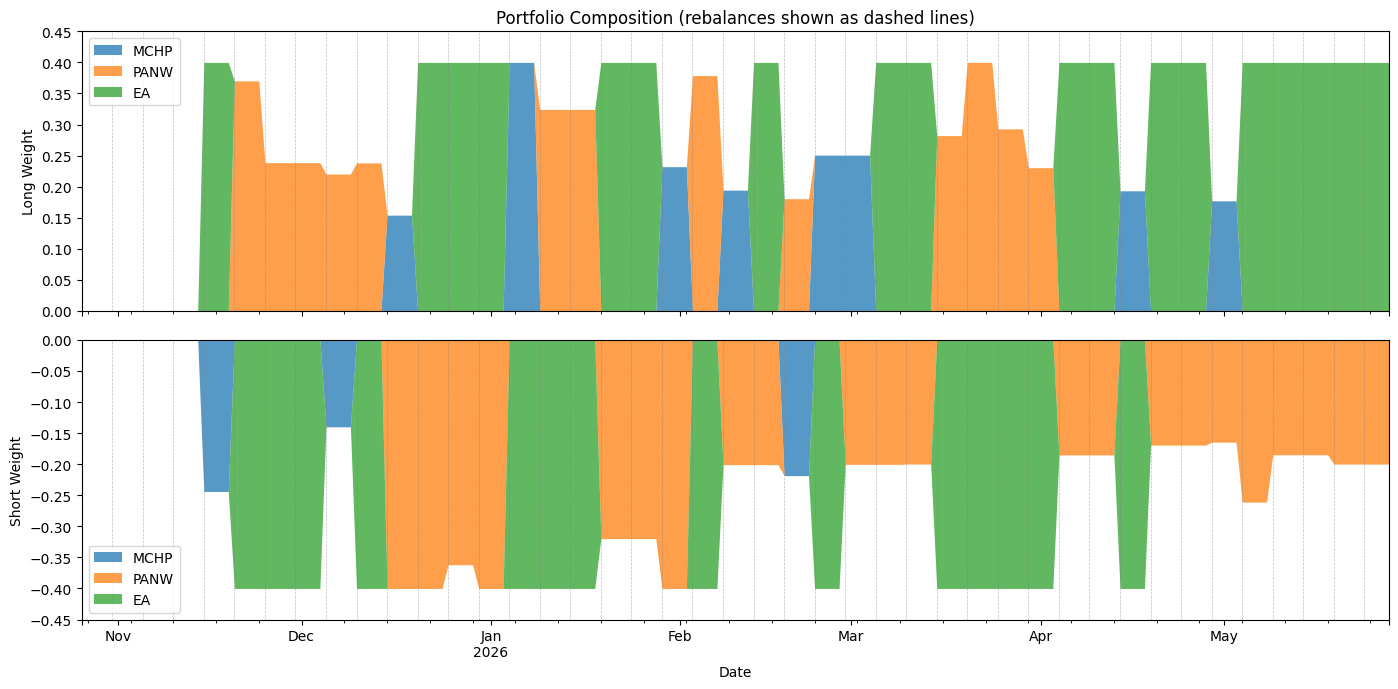

In [57]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# separate long and short so negatives don't cancel positives in the stack
longs  = weights_daily.clip(lower=0)
shorts = weights_daily.clip(upper=0)

# top panel: long allocations
longs.plot.area(ax=axes[0], alpha=0.75, linewidth=0)
axes[0].set_ylabel("Long Weight")
axes[0].set_ylim(0, MAX_POS + 0.05)

# bottom panel: short allocations (negative weights)
shorts.plot.area(ax=axes[1], alpha=0.75, linewidth=0)
axes[1].set_ylabel("Short Weight")
axes[1].set_ylim(-MAX_POS - 0.05, 0)

# mark every rebalance with a vertical line on both panels
for d in rebal_dates:
  axes[0].axvline(d, color='grey', linewidth=0.5, linestyle='--', alpha=0.5)
  axes[1].axvline(d, color='grey', linewidth=0.5, linestyle='--', alpha=0.5)

axes[0].set_title("Portfolio Composition (rebalances shown as dashed lines)")
axes[0].legend(loc='upper left')
axes[1].legend(loc='lower left')
plt.tight_layout()
plt.show()

In [134]:
def har_vol_forecast_5d(daily_rets):
      """
      Fit HAR on daily squared returns from IS window.
      Returns a 5-day vol forecast to match the prediction horizon.
      """
      rv = (daily_rets ** 2).dropna()

      model  = HARX(rv, lags=[1, 5, 22], rescale=False)
      result = model.fit(disp='off')

      fc = result.forecast(horizon=1, reindex=False)
      daily_vol = np.sqrt(max(fc.mean.iloc[-1, 0], 1e-8))

      return daily_vol * np.sqrt(5)    # scale to 5-day horizon

In [150]:
device      = "xpu"
MIN_IS_LEN  = 252
OOS_LEN     = 5
INIT_EPOCHS = 10
FINE_EPOCHS = 5
REPLAY_SIZE = 64      # historical windows mixed into each fine-tune step
FINE_LR     = 5e-4   # reset at every step — never permanently decays
TARGET_VOL  = 0.15 / np.sqrt(52)
MAX_POS     = 0.80
n_targets   = len(chosen)

In [138]:
model     = LPATCHTST(n_channels=df3.shape[1], n_targets=n_targets).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.MSELoss()
all_preds    = []
all_har_vols = []

rebal_positions = range(MIN_IS_LEN, len(df3) - OOS_LEN + 1, OOS_LEN)

for step, pos in enumerate(tqdm(rebal_positions, desc="Walk-forward")):
  is_df  = df3.iloc[0 : pos]
  oos_df = df3.iloc[pos : pos + OOS_LEN]

  if step == 0:
      # ── cold start ────────────────────────────────────────────────
      for pg in optimizer.param_groups:
          pg['lr'] = 1e-3

      train_ds = ReturnDataset(is_df.values, n_targets)
      train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)

      model.train()
      for _ in range(INIT_EPOCHS):
          for X, y in train_dl:
              optimizer.zero_grad()
              loss = criterion(model(X.permute(1, 0, 2).to(device)), y.to(device))
              loss.backward()
              nn.utils.clip_grad_norm_(model.parameters(), 1.0)
              optimizer.step()

  else:
      # ── fine-tune: new 5 samples + replay buffer ──────────────────
      # fix 1: reset LR each step — never permanently stuck
      for pg in optimizer.param_groups:
          pg['lr'] = FINE_LR

      # new samples (5 windows with LOOKBACK context)
      new_chunk = df3.iloc[pos - OOS_LEN - LOOKBACK : pos]
      new_ds    = ReturnDataset(new_chunk.values, n_targets)
      new_X, new_y = zip(*[new_ds[i] for i in range(len(new_ds))])
      new_X = torch.stack(new_X)   # (5, LOOKBACK, n_features)
      new_y = torch.stack(new_y)   # (5, n_targets)

      # fix 2+3: replay buffer — random windows from full IS history
      is_arr     = torch.tensor(is_df.values, dtype=torch.float32)
      n_replay   = min(REPLAY_SIZE, len(is_arr) - LOOKBACK - 1)
      starts     = torch.randperm(len(is_arr) - LOOKBACK)[:n_replay]
      replay_X   = torch.stack([is_arr[s : s + LOOKBACK] for s in starts])
      replay_y   = torch.stack([is_arr[s + LOOKBACK, :n_targets] for s in starts])

      # combine: 5 new + 64 replay = 69 samples, stable gradient
      comb_dl = DataLoader(
          torch.utils.data.TensorDataset(
              torch.cat([new_X, replay_X]),   # (69, LOOKBACK, features)
              torch.cat([new_y, replay_y]),   # (69, n_targets)
          ),
          batch_size=32, shuffle=True
      )

      model.train()
      for _ in range(FINE_EPOCHS):
          for X, y in comb_dl:
              optimizer.zero_grad()
              loss = criterion(model(X.permute(1, 0, 2).to(device)), y.to(device))
              loss.backward()
              nn.utils.clip_grad_norm_(model.parameters(), 1.0)
              optimizer.step()

  # ── HAR vol: every step — OLS on daily data is fast ──────────────
  daily_rets_is = df.loc[is_df.index, list(chosen)].pct_change().dropna()
  har_vols      = np.array([har_vol_forecast_5d(daily_rets_is[t]) for t in chosen])

  all_har_vols.append(pd.DataFrame(
      [har_vols] * OOS_LEN, index=oos_df.index, columns=chosen
  ))

  # ── predict at rebalance date ─────────────────────────────────────
  ctx     = torch.tensor(is_df.values[-LOOKBACK:], dtype=torch.float32)
  x_input = ctx.unsqueeze(1).to(device)

  model.eval()
  with torch.no_grad():
      pred = model(x_input).cpu().squeeze(0).numpy()

  all_preds.append(pd.DataFrame(
      [pred] * OOS_LEN, index=oos_df.index, columns=list(chosen)
  ))

Walk-forward: 100%|██████████| 235/235 [07:46<00:00,  1.98s/it]


In [151]:
# ── assemble full backtest signal ────────────────────────────────────
ret_preds_full = pd.concat(all_preds)
ret_preds      = ret_preds_full.iloc[:, :len(chosen)].copy()
ret_preds.columns = list(chosen)

# cross-sectional rank → demeaned signal (long/short market-neutral)
ranked      = ret_preds.rank(axis=1)
base_alloc  = ranked.sub(ranked.mean(axis=1), axis=0)          # demean
base_alloc = base_alloc.clip(lower=0) # no shorts
base_alloc  = base_alloc.div(base_alloc.abs().sum(axis=1), axis=0)  # |sum|=1

# vol-scale: shrink large positions in high-vol names
har_vol_df = pd.concat(all_har_vols)
vol_scaled = base_alloc.div(har_vol_df + 1e-8)   # ← HAR vol instead of rolling std
vol_scaled = vol_scaled.mul(TARGET_VOL)
vol_scaled = vol_scaled.clip(0, MAX_POS)

In [152]:
REBAL_THRESHOLD = 0.05   # only rebalance a position if weight shifts by >5%

# forward-fill current weights and only update where delta > threshold
weights_5d    = vol_scaled
prev_weights  = weights_5d.shift(1).fillna(0)
delta         = (weights_5d - prev_weights).abs()
# keep old weight where change is small
weights_5d    = prev_weights.where(delta < REBAL_THRESHOLD, weights_5d)

# expand 5-day weights to daily grid (hold position between rebalances)
weights_daily = weights_5d.reindex(ret_preds.index).ffill().fillna(0)

In [153]:
close_bt = df.loc[ret_preds.index, list(chosen)]
pf = vbt.Portfolio.from_orders(
  close     = close_bt,
  size      = weights_daily,
  size_type = 'targetpercent',
  fees      = 0.001,      # 10 bps one-way commission
  slippage  = 0.0005,     # 5 bps market impact
  freq      = '1D',
)

print(pf.stats(group_by=True))
# pf.plot(column=chosen[0]).show()

# turnover per year — proxy for tax drag
daily_turnover = weights_daily.diff().abs().sum(axis=1)
print(f"Ann. turnover: {daily_turnover.sum() / (len(ret_preds.index)/252):.1%}")

Start Index                   2023-03-09 00:00:00+00:00
End Index                     2026-05-26 00:00:00+00:00
Total Duration                       1175 days 00:00:00
Start Value                                       300.0
Min Value                                    266.221071
Max Value                                    315.131512
End Value                                    309.161943
Total Return [%]                               3.053981
Benchmark Return [%]                          92.710135
Position Coverage [%]                             100.0
Max Gross Exposure [%]                        31.159605
Max Drawdown [%]                              15.520644
Max Drawdown Duration                1064 days 00:00:00
Total Orders                                       1319
Total Fees Paid                               16.672521
Total Trades                                        833
Win Rate [%]                                  54.447115
Best Trade [%]                                31

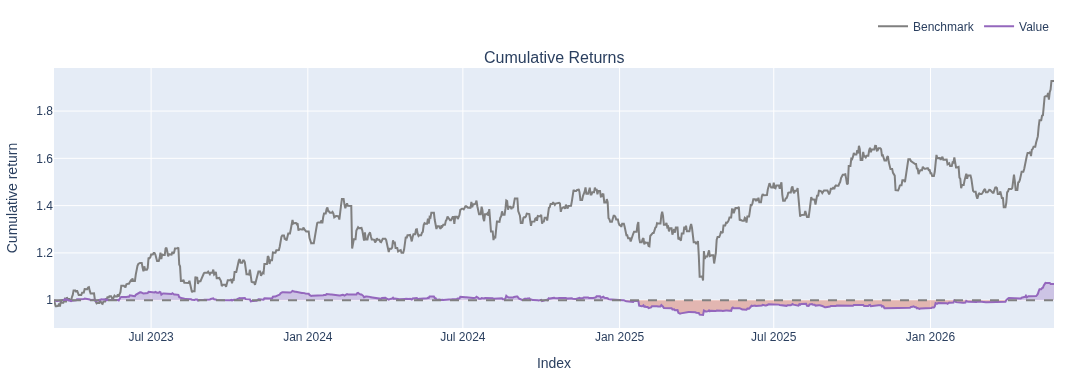

In [147]:
pf.regroup(group_by=True).plot().show()